# 🔎 Fase SEMMA — Explore (Exploração)

## Objetivo
A etapa de exploração tem como objetivo compreender profundamente os dados, identificando padrões, inconsistências, relações entre variáveis e possíveis problemas que possam impactar a modelagem.


## 📊 Análise Descritiva
Inicialmente, foi realizada a análise estatística básica para entender o comportamento geral das variáveis.

Principais ações:
- Cálculo de métricas como média, mediana, desvio padrão, mínimo e máximo
- Identificação de distribuições
- Avaliação da escala das variáveis

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_train = pd.read_csv("../data/processed/train_data.csv")
df_test = pd.read_csv("../data/processed/test_data.csv")

In [4]:
### Comparação automatica de descrição entre os dados de treino e teste
def generateDescribe(train,test,col):
    df_temp = train[col].describe().reset_index()
    df_temp.columns = ["metrica",f"train_{col}"]
    df_temp[f"test_{col}"] = test[col].describe().values
    df_temp = df_temp.set_index("metrica")
    return df_temp

In [5]:
print(f"Dados de treino : Linhas {df_train.shape[0]} | Colunas {df_train.shape[1]}" )
print(f"Dados de teste  : Linhas {df_test.shape[0]} | Colunas {df_test.shape[1]}" )

Dados de treino : Linhas 150000 | Colunas 11
Dados de teste  : Linhas 101503 | Colunas 11


### Calculo de metricas

#### Simetria

In [ ]:
df_train.skew(numeric_only=True)

In [ ]:
df_mean = df_train.mean(numeric_only=True).reset_index()
df_mean["Mediana"] = df_train.median(numeric_only=True).reset_index()[0]
df_mean

,index,0,Mediana
0,SeriousDlqin2yrs,0.066840,0.000000
1,RevolvingUtilizationOfUnsecuredLines,6.048438,0.154181
2,age,52.295207,52.000000
3,NumberOfTime30-59DaysPastDueNotWorse,0.421033,0.000000
4,DebtRatio,353.005076,0.366508
5,MonthlyIncome,6670.221237,5400.000000
6,NumberOfOpenCreditLinesAndLoans,8.452760,8.000000
7,NumberOfTimes90DaysLate,0.265973,0.000000
8,NumberRealEstateLoansOrLines,1.018240,1.000000
9,NumberOfTime60-89DaysPastDueNotWorse,0.240387,0.000000


##### Conclusão 
Identificada uma grande assimetria em praticamente todas as variaveis mas principalmente 
- DebtRatio
- RevolvingUtilizationOfUnsecuredLines
- MonthlyIncome

<br>Necessário tratamento de outlier ou normalização 

In [ ]:
generateDescribe(df_train,df_test,"age")

,train_age,test_age
metrica,,
count,150000.000000,101503.000000
mean,52.295207,52.405436
std,14.771866,14.779756
min,0.000000,21.000000
25%,41.000000,41.000000
50%,52.000000,52.000000
75%,63.000000,63.000000
max,109.000000,104.000000




##  Criação de Amostras
Para garantir uma avaliação adequada do modelo, os dados são divididos em:

- **Treino**: utilizado para ajuste do modelo
- **Validação**: utilizado para tuning de hiperparâmetros
- **Teste**: utilizado para avaliação final

A divisão é realizada de forma aleatória, preservando a proporção das classes (estratificação, quando aplicável).

---

## ⚖️ Verificação de Balanceamento de Classes
A variável alvo é analisada para identificar possível desbalanceamento entre as classes (inadimplente vs. não inadimplente).

Etapas realizadas:
- Cálculo da proporção de cada classe
- Avaliação do impacto do desbalanceamento no modelo

Caso necessário, técnicas de balanceamento poderão ser aplicadas nas etapas seguintes.

---

## ⚡ Redução de Volume de Dados
Para acelerar o desenvolvimento e experimentação:
- Pode ser utilizada uma amostra reduzida do dataset
- Mantida a representatividade estatística dos dados

Essa abordagem permite ciclos mais rápidos de teste e validação.

---

## 🚨 Prevenção de Data Leakage
São adotadas práticas para evitar vazamento de dados, garantindo que o modelo não tenha acesso a informações futuras ou indevidas.

Cuidados aplicados:
- Separação correta entre treino, validação e teste antes de qualquer transformação
- Evitar uso de variáveis derivadas diretamente da variável alvo
- Aplicação de transformações (ex: normalização, encoding) apenas com base nos dados de treino

---

## ✅ Resultado Esperado
Ao final desta etapa, espera-se:
- Dados organizados e prontos para exploração
- Amostras bem definidas
- Base consistente e sem vazamento de informação

## Análise de Dados Ausentes
Verificação da presença de valores nulos no dataset.

Etapas realizadas:
- Identificação de colunas com valores faltantes
- Cálculo da proporção de dados ausentes por variável
- Avaliação da necessidade de imputação ou exclusão

### Total de nulos

In [ ]:
df_train.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [ ]:
df_test.isnull().sum()

RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           20103
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       2626
dtype: int64

### Percentual de nulos

In [ ]:
df_train.isnull().mean()

SeriousDlqin2yrs                        0.000000
RevolvingUtilizationOfUnsecuredLines    0.000000
age                                     0.000000
NumberOfTime30-59DaysPastDueNotWorse    0.000000
DebtRatio                               0.000000
MonthlyIncome                           0.198207
NumberOfOpenCreditLinesAndLoans         0.000000
NumberOfTimes90DaysLate                 0.000000
NumberRealEstateLoansOrLines            0.000000
NumberOfTime60-89DaysPastDueNotWorse    0.000000
NumberOfDependents                      0.026160
dtype: float64

In [ ]:
df_test.isnull().mean()

RevolvingUtilizationOfUnsecuredLines    0.000000
age                                     0.000000
NumberOfTime30-59DaysPastDueNotWorse    0.000000
DebtRatio                               0.000000
MonthlyIncome                           0.198053
NumberOfOpenCreditLinesAndLoans         0.000000
NumberOfTimes90DaysLate                 0.000000
NumberRealEstateLoansOrLines            0.000000
NumberOfTime60-89DaysPastDueNotWorse    0.000000
NumberOfDependents                      0.025871
dtype: float64

# Distribuição

## Idade

In [ ]:
generateDescribe(df_train,df_test,"age")

,train_age,test_age
metrica,,
count,150000.000000,101503.000000
mean,52.295207,52.405436
std,14.771866,14.779756
min,0.000000,21.000000
25%,41.000000,41.000000
50%,52.000000,52.000000
75%,63.000000,63.000000
max,109.000000,104.000000


<Axes: xlabel='SeriousDlqin2yrs', ylabel='age'>

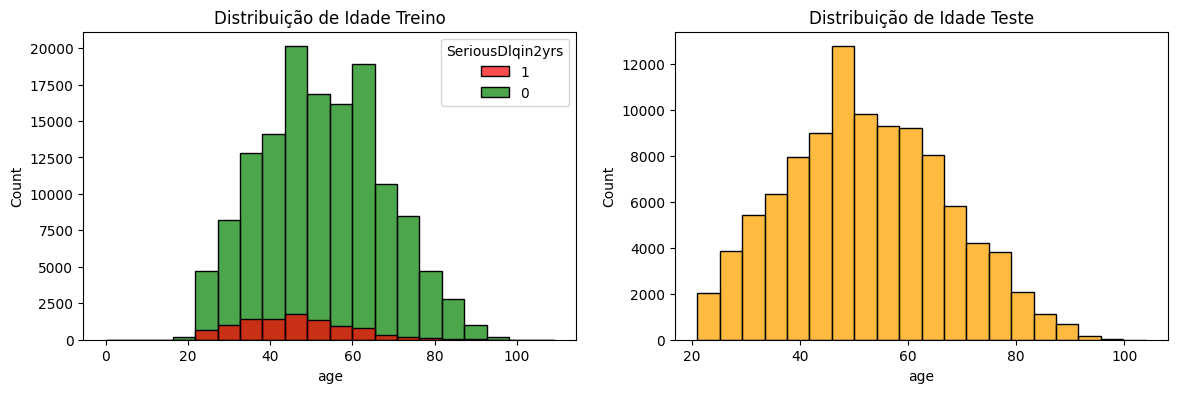

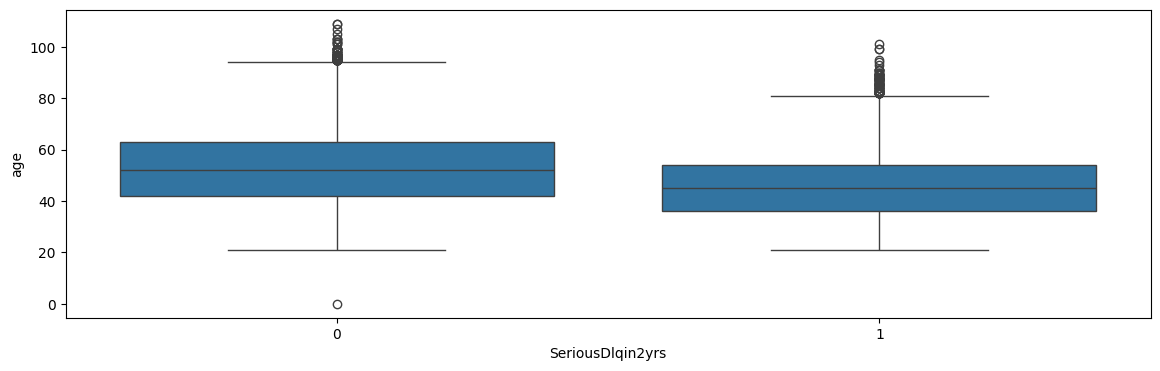

In [ ]:
fig, axis = plt.subplots(1,2,figsize=(14, 4))
axis[0].set_title("Distribuição de Idade Treino")
sns.histplot(df_train,x="age",bins=20,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[1].set_title("Distribuição de Idade Teste")
sns.histplot(df_test,x="age",bins=20,ax=axis[1],color="orange")
bins = range(0,df_train["age"].max(),20)
fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="age",x="SeriousDlqin2yrs")

Apesar do desbalanceamento é possivel avaliar uma boa proporção entre as classes e um comportamento semelhante entre os dados de treino e teste 

# NumberOfTime30-59DaysPastDueNotWorse

In [ ]:
generateDescribe(df_train,df_test,"NumberOfTime30-59DaysPastDueNotWorse")

,train_NumberOfTime30-59DaysPastDueNotWorse,test_NumberOfTime30-59DaysPastDueNotWorse
metrica,,
count,150000.000000,101503.000000
mean,0.421033,0.453770
std,4.192781,4.538487
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,98.000000,98.000000


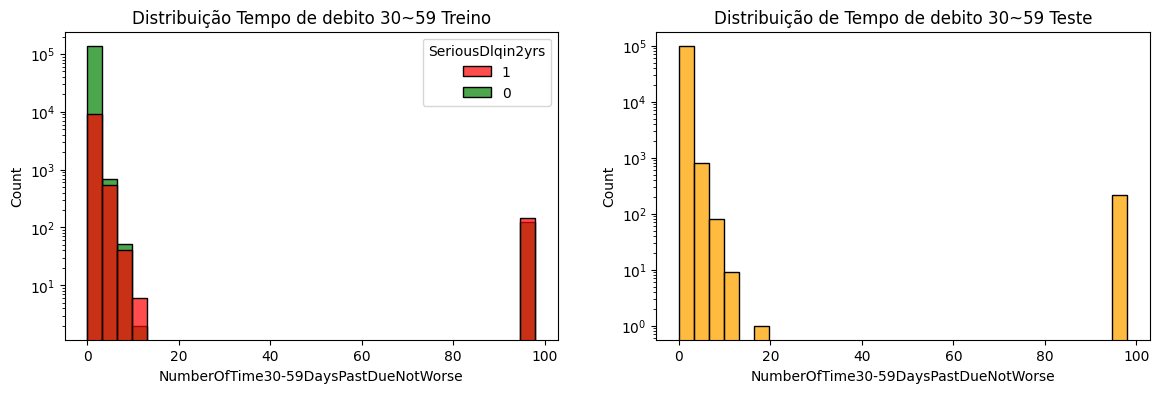

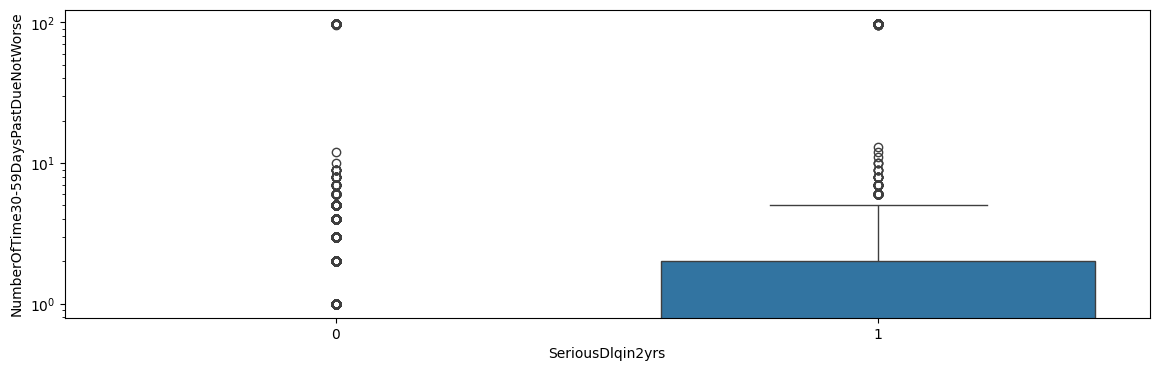

In [ ]:
fig, axis = plt.subplots(1,2,figsize=(14, 4))
axis[0].set_title("Distribuição Tempo de debito 30~59 Treino")
sns.histplot(df_train,x="NumberOfTime30-59DaysPastDueNotWorse",bins=30,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[1].set_title("Distribuição de Tempo de debito 30~59 Teste")
sns.histplot(df_test,x="NumberOfTime30-59DaysPastDueNotWorse",bins=30,ax=axis[1],color="orange")
axis[1].set_yscale("log")

fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="NumberOfTime30-59DaysPastDueNotWorse",x="SeriousDlqin2yrs")
axis.set_yscale("log")

Aqui ja é possivel identificar uma grande diferença entre o comportamento, principalmente na presença de outliers

# DebtRatio

In [ ]:
generateDescribe(df_train,df_test,"DebtRatio")

,train_DebtRatio,test_DebtRatio
metrica,,
count,150000.000000,101503.000000
mean,353.005076,344.475020
std,2037.818523,1632.595231
min,0.000000,0.000000
25%,0.175074,0.173423
50%,0.366508,0.364260
75%,0.868254,0.851619
max,329664.000000,268326.000000


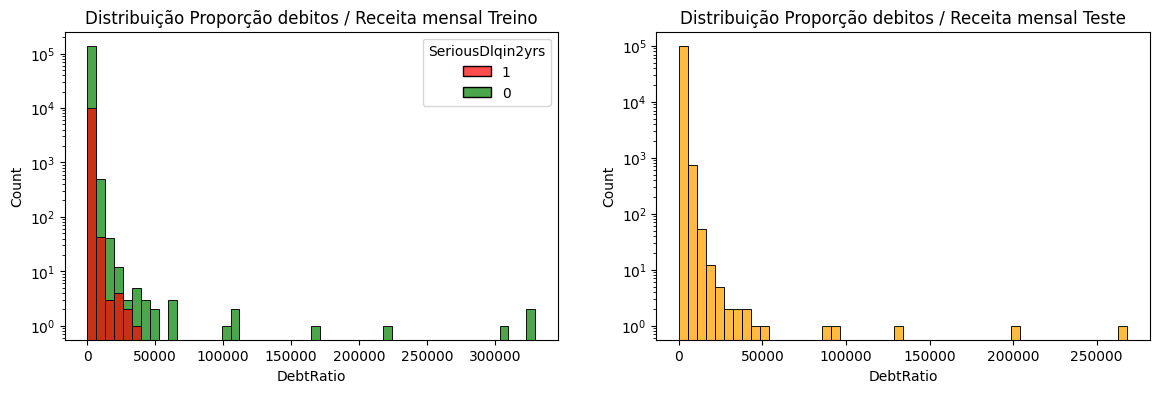

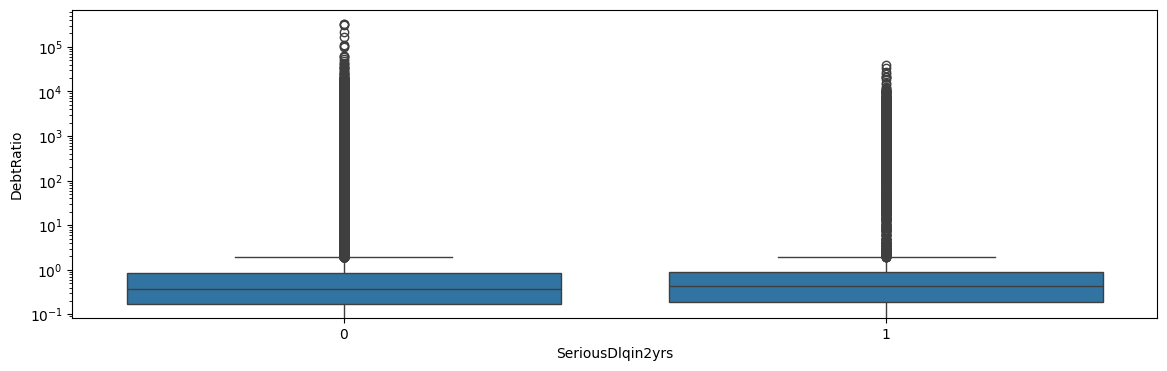

In [ ]:
fig, axis = plt.subplots(1,2,figsize=(14, 4))
axis[0].set_title("Distribuição Proporção debitos / Receita mensal Treino")
sns.histplot(df_train,x="DebtRatio",bins=50,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[1].set_title("Distribuição Proporção debitos / Receita mensal Teste")
sns.histplot(df_test,x="DebtRatio",bins=50,ax=axis[1],color="orange")
axis[1].set_yscale("log")

fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="DebtRatio",x="SeriousDlqin2yrs")
axis.set_yscale("log")

É possivel analisar que, apartir de um ceto DebtRatio a inadimplencia (classe 1) se torna pouco frequente em torno de 50000. Tambem é possivel analisar que a media do DebtRatio é maior para essa classe indicando um comportamento a ser avaliado

## Receita mensal

In [ ]:
generateDescribe(df_train,df_test,"MonthlyIncome")

,train_MonthlyIncome,test_MonthlyIncome
metrica,,
count,1.202690e+05,8.140000e+04
mean,6.670221e+03,6.855036e+03
std,1.438467e+04,3.650860e+04
min,0.000000e+00,0.000000e+00
25%,3.400000e+03,3.408000e+03
50%,5.400000e+03,5.400000e+03
75%,8.249000e+03,8.200000e+03
max,3.008750e+06,7.727000e+06


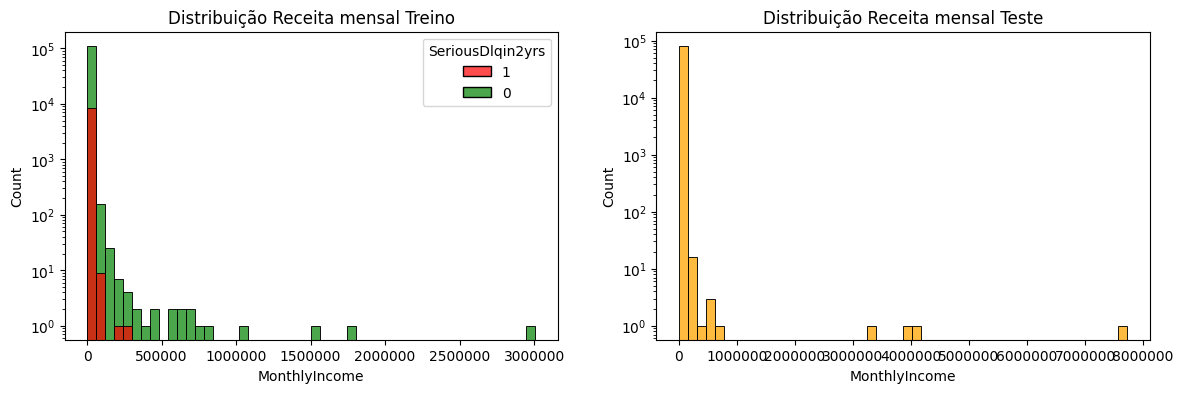

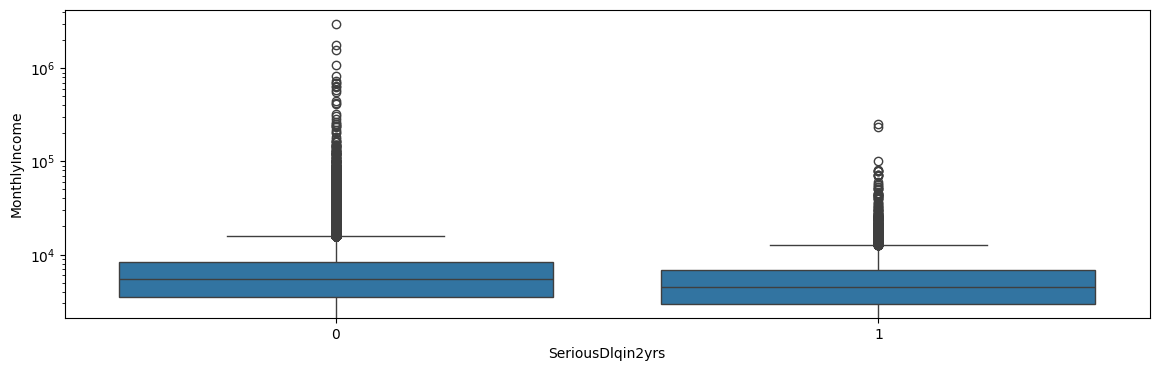

In [ ]:
fig, axis = plt.subplots(1,2,figsize=(14, 4))
axis[0].set_title("Distribuição Receita mensal Treino")
sns.histplot(df_train,x="MonthlyIncome",bins=50,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[0].ticklabel_format(style='plain', axis='x')
axis[1].set_title("Distribuição Receita mensal Teste")
sns.histplot(df_test,x="MonthlyIncome",bins=50,ax=axis[1],color="orange")
axis[1].set_yscale("log")
axis[1].ticklabel_format(style='plain', axis='x')

fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="MonthlyIncome",x="SeriousDlqin2yrs")
axis.set_yscale("log")

A renda mensal tem um comportamento bastante proximo entre as classes 0 e 1 porem é possivel analisar que apartir de um determinado valor a possibilidade de inadimplencia cai bastante tambem

## Emprestimos Ativos

In [ ]:
generateDescribe(df_train,df_test,"NumberOfOpenCreditLinesAndLoans")

,train_NumberOfOpenCreditLinesAndLoans,test_NumberOfOpenCreditLinesAndLoans
metrica,,
count,150000.000000,101503.000000
mean,8.452760,8.453514
std,5.145951,5.144100
min,0.000000,0.000000
25%,5.000000,5.000000
50%,8.000000,8.000000
75%,11.000000,11.000000
max,58.000000,85.000000


<Axes: xlabel='SeriousDlqin2yrs', ylabel='NumberOfOpenCreditLinesAndLoans'>

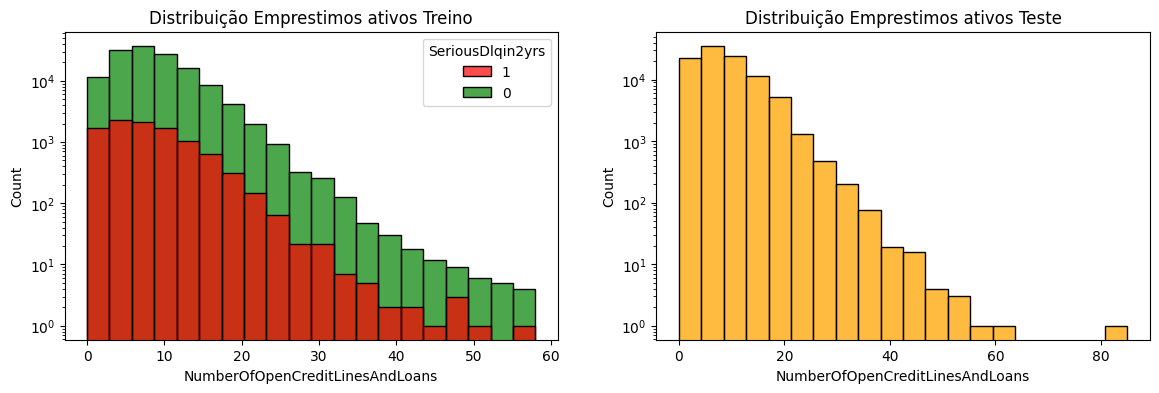

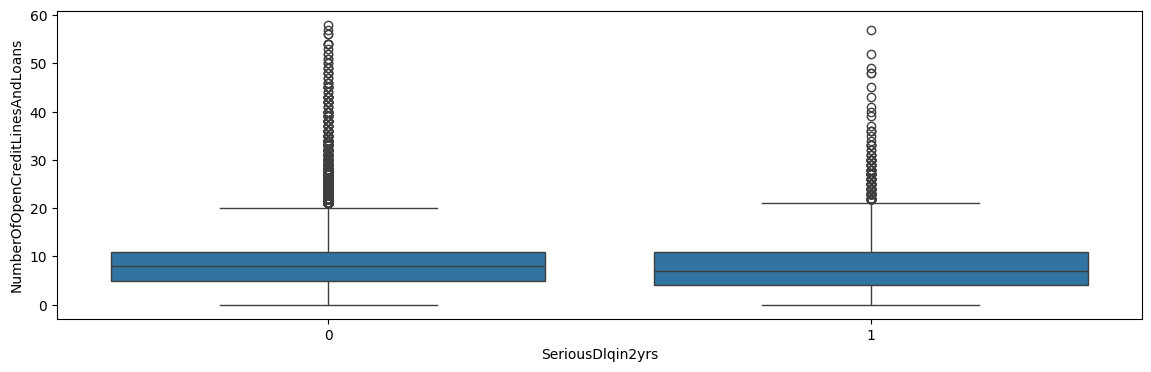

In [ ]:
fig, axis = plt.subplots(1,2,figsize=(14, 4))
axis[0].set_title("Distribuição Emprestimos ativos Treino")
sns.histplot(df_train,x="NumberOfOpenCreditLinesAndLoans",bins=20,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[0].ticklabel_format(style='plain', axis='x')
axis[1].set_title("Distribuição Emprestimos ativos Teste")
sns.histplot(df_test,x="NumberOfOpenCreditLinesAndLoans",bins=20,ax=axis[1],color="orange")
axis[1].set_yscale("log")
axis[1].ticklabel_format(style='plain', axis='x')

fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="NumberOfOpenCreditLinesAndLoans",x="SeriousDlqin2yrs")
#axis.set_yscale("log")

O bomportamento avaliado no boxplot demonstra que a variancia entre as classes são bastante parecidas sendo dificil descrever um comportamento, o que se confirma quando avaliamos o histograma e vemos um comportamento bem semelhande na distribuição pelo tempo.

## Numero de atrasos mais de 90 dias

In [ ]:
generateDescribe(df_train,df_test,"NumberOfTimes90DaysLate")

,train_NumberOfTimes90DaysLate,test_NumberOfTimes90DaysLate
metrica,,
count,150000.000000,101503.000000
mean,0.265973,0.296691
std,4.169304,4.515859
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,98.000000,98.000000


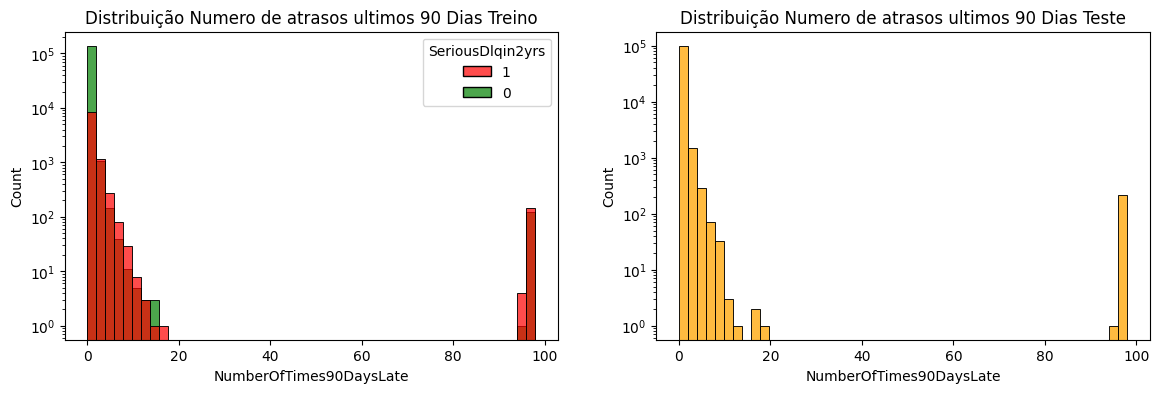

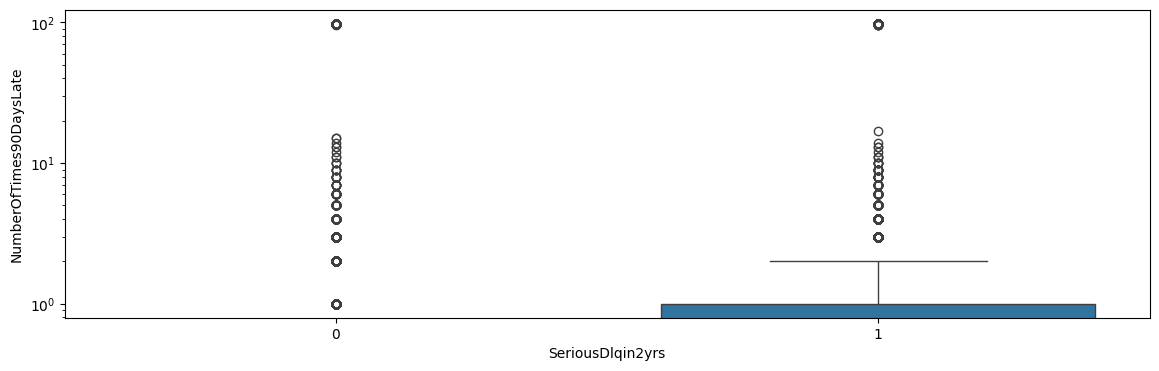

In [ ]:
fig, axis = plt.subplots(1,2,figsize=(14, 4))
axis[0].set_title("Distribuição Numero de atrasos ultimos 90 Dias Treino")
sns.histplot(df_train,x="NumberOfTimes90DaysLate",bins=50,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[0].ticklabel_format(style='plain', axis='x')
axis[1].set_title("Distribuição Numero de atrasos ultimos 90 Dias Teste")
sns.histplot(df_test,x="NumberOfTimes90DaysLate",bins=50,ax=axis[1],color="orange")
axis[1].set_yscale("log")
axis[1].ticklabel_format(style='plain', axis='x')

fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="NumberOfTimes90DaysLate",x="SeriousDlqin2yrs")
axis.set_yscale("log")

Por ser uma variavel diretamente relacionada com o target, conseguimos avaliar um comportamento bem distinto entre as classes 

## Hipotecas e emprestimos imobiliarios

In [ ]:
generateDescribe(df_train,df_test,"NumberRealEstateLoansOrLines")


,train_NumberRealEstateLoansOrLines,test_NumberRealEstateLoansOrLines
metrica,,
count,150000.000000,101503.000000
mean,1.018240,1.013074
std,1.129771,1.110253
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,54.000000,37.000000


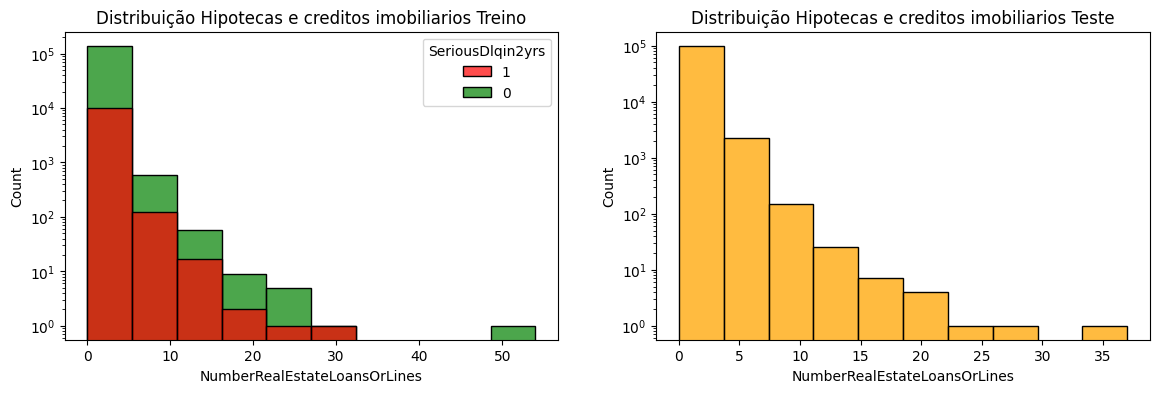

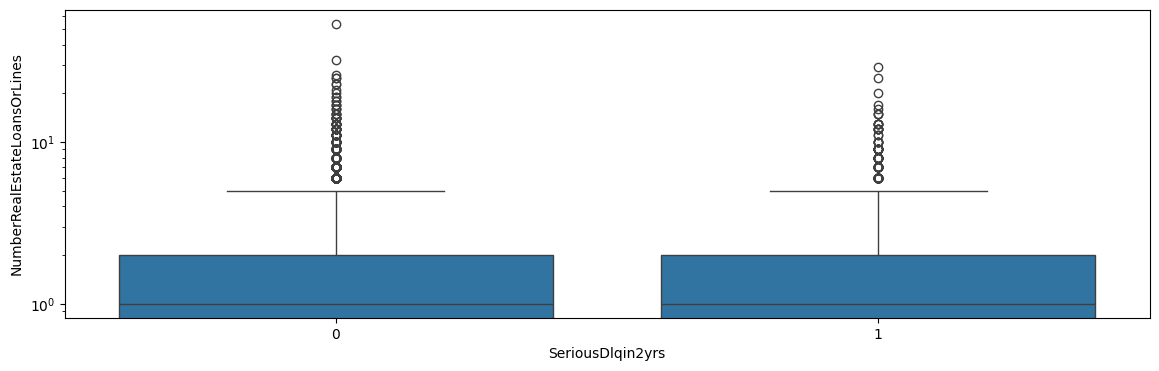

In [ ]:
fig, axis = plt.subplots(1,2,figsize=(14, 4))
axis[0].set_title("Distribuição Hipotecas e creditos imobiliarios Treino")
sns.histplot(df_train,x="NumberRealEstateLoansOrLines",bins=10,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[0].ticklabel_format(style='plain', axis='x')
axis[1].set_title("Distribuição Hipotecas e creditos imobiliarios Teste")
sns.histplot(df_test,x="NumberRealEstateLoansOrLines",bins=10,ax=axis[1],color="orange")
axis[1].set_yscale("log")
axis[1].ticklabel_format(style='plain', axis='x')

fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="NumberRealEstateLoansOrLines",x="SeriousDlqin2yrs")
axis.set_yscale("log")


Essa variavel tembem tem um comportamento bastante proximo entre as classes 

## Mais de 90 dias em atraso

In [ ]:
generateDescribe(df_train,df_test,"NumberOfTime60-89DaysPastDueNotWorse")

,train_NumberOfTime60-89DaysPastDueNotWorse,test_NumberOfTime60-89DaysPastDueNotWorse
metrica,,
count,150000.000000,101503.000000
mean,0.240387,0.270317
std,4.155179,4.503578
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,98.000000,98.000000


<Axes: xlabel='SeriousDlqin2yrs', ylabel='NumberOfTime60-89DaysPastDueNotWorse'>

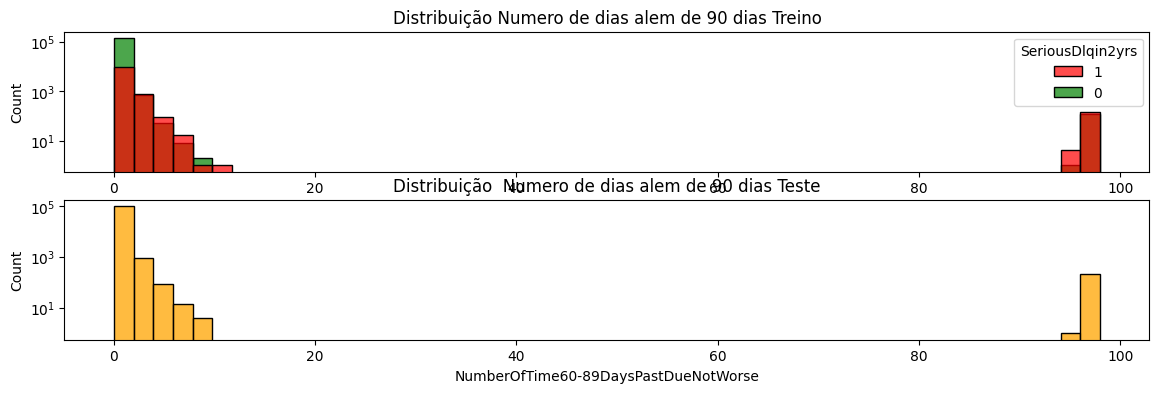

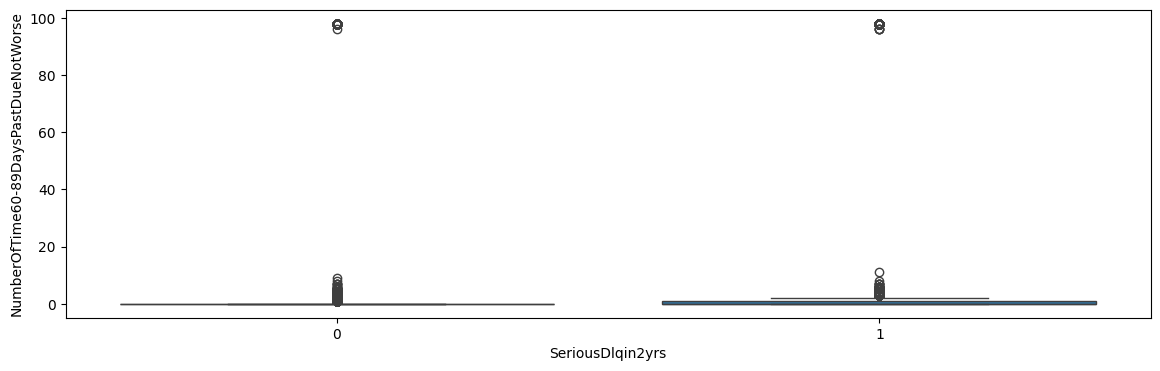

In [ ]:
fig, axis = plt.subplots(2,1,figsize=(14, 4))
axis[0].set_title("Distribuição Numero de dias alem de 90 dias Treino")
sns.histplot(df_train,x="NumberOfTime60-89DaysPastDueNotWorse",bins=50,hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[0].ticklabel_format(style='plain', axis='x')
axis[1].set_title("Distribuição  Numero de dias alem de 90 dias Teste")
sns.histplot(df_test,x="NumberOfTime60-89DaysPastDueNotWorse",bins=50,ax=axis[1],color="orange")
axis[1].set_yscale("log")
axis[1].ticklabel_format(style='plain', axis='x')

fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="NumberOfTime60-89DaysPastDueNotWorse",x="SeriousDlqin2yrs")

Aqui tambem é possivel analisar um comportamento semelhante a vaiavel NumberOfTimes90DaysLate, por ser uma variavel bastante relacionada

## Numero de dependentes

In [ ]:
generateDescribe(df_train,df_test,"NumberOfDependents")

,train_NumberOfDependents,test_NumberOfDependents
metrica,,
count,150000.000000,101503.000000
mean,0.744351,0.755810
std,1.104461,1.126064
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,1.000000
max,20.000000,43.000000


<Axes: xlabel='SeriousDlqin2yrs', ylabel='NumberOfDependents'>

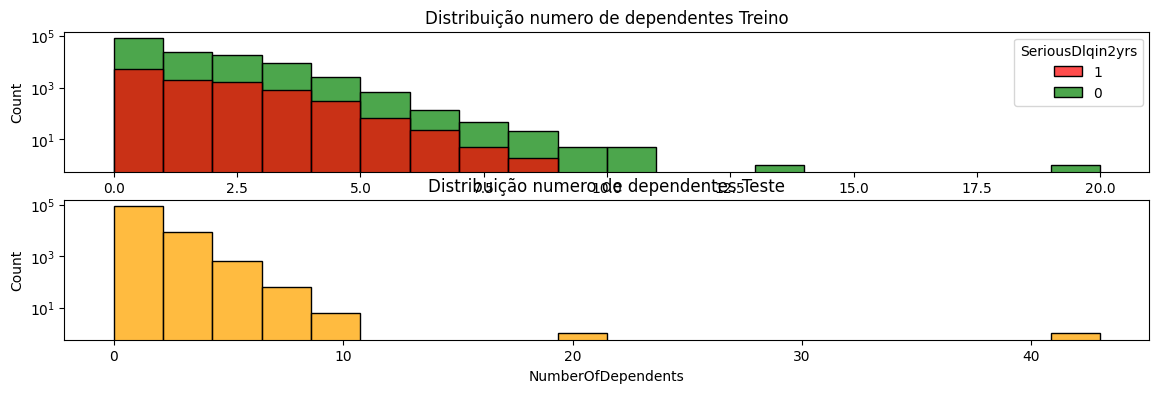

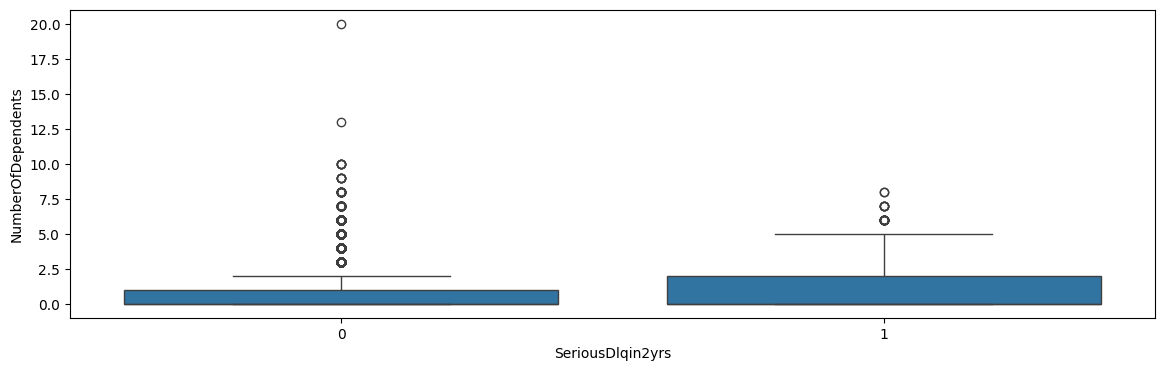

In [ ]:
fig, axis = plt.subplots(2,1,figsize=(14, 4))
axis[0].set_title("Distribuição numero de dependentes Treino")
sns.histplot(df_train,x="NumberOfDependents",bins=int(df_train["NumberOfDependents"].max()),hue="SeriousDlqin2yrs",ax=axis[0],hue_order=[1, 0],palette={0: "green", 1: "red"}, alpha=.7)
axis[0].set_yscale("log")
axis[0].ticklabel_format(style='plain', axis='x')

axis[1].set_title("Distribuição numero de dependentes Teste")
sns.histplot(df_test,x="NumberOfDependents",bins=20,ax=axis[1],color="orange")
axis[1].set_yscale("log")
axis[1].ticklabel_format(style='plain', axis='x')

fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.boxplot(df_train,y="NumberOfDependents",x="SeriousDlqin2yrs")

Podemos ver um aumento de valores dentro da classe de inadimplentes conforme o aumento de dependentes, porem dentro da distribuição é possivel perceber que esse aumento não necesariamente é determinante visto que os maiores valores de dependentes estão na classe de adinplencia

# Matriz de correlação 

<Axes: >

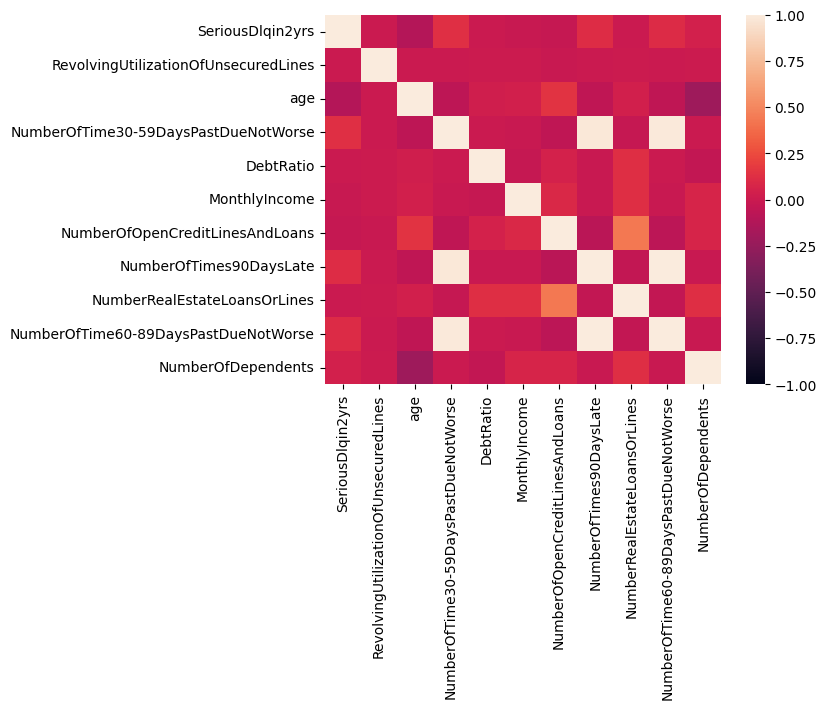

In [ ]:
sns.heatmap(df_train.corr(), vmin=-1, vmax=1)

É possivel ver uma correlação majoritariamente proxima a 0 indicando uma baixa relaçãop linear, isso deve ser levando em conta na criação do modelo

In [ ]:
fig, axis = plt.subplots(1,1,figsize=(14, 4))
sns.pairplot(df_train,hue="SeriousDlqin2yrs",hue_order=[1, 0],palette={0: "green", 1: "red"},ax=axis[0])

NameError: name 'plt' is not defined